In [1]:
import pandas as pd
import numpy as num_paths
import matplotlib.pyplot as psnrResault
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from matplotlib import pyplot as plt

/home/gurhancoban/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df=pd.read_csv("data09102024.csv")

In [3]:
df=pd.DataFrame(df)
df.head()

,host,avgRTT,packetLoss,latency,hopCount,bandwidth,psnr,ssim_first,ssim_second,kaynak,...,kayip,kayip_orani,h10gelen,h10giden,h10toplam,h14gelen,h14giden,h14toplam,type,server
0,h13,204.792,0.0,31,2,10000000,36.507699,0.996039,24.022245,67209812,...,-161196,0.000000,4776,39462,44238.0,5072.0,39251.0,44323.0,3.0,h10
1,h1,336.581,0.0,78,3,10000000,35.079593,0.994246,22.400471,67209812,...,-161196,0.000000,962710,44650,1051598.0,5072.0,40267.0,89662.0,3.0,h14
2,h2,260.959,0.0,72,3,10000000,36.081554,0.994275,22.422055,67209812,...,100948,0.390038,3095346,57173,4204117.0,983906.0,47582.0,1121150.0,3.0,h14
3,h3,239.227,0.0,52,2,10000000,29.715019,0.982092,17.469591,67209812,...,1149524,1.950191,5181362,67595,9453074.0,4075282.0,62326.0,5258758.0,3.0,h14
4,h4,409.193,0.0,81,3,10000000,35.194807,0.993585,21.927812,67209812,...,100948,0.390038,7274784,84244,16812102.0,9233590.0,87819.0,14580167.0,3.0,h10


In [4]:
df["mos"]=6
df.shape[0]
for i in range(0,df.shape[0],1):
    if df.ssim_first[i]>=0.99:
        df.mos[i]=5
    elif df.ssim_first[i]>=0.95 and df.ssim_first[i]<0.99:
        df.mos[i]=4
    elif df.ssim_first[i]>=0.88 and df.ssim_first[i]<0.95:
        df.mos[i]=3
    elif df.ssim_first[i]>=0.5 and df.ssim_first[i]<0.88:
        df.mos[i]=2
    elif df.ssim_first[i]<0.5:
        df.mos[i]=1

df

,host,avgRTT,packetLoss,latency,hopCount,bandwidth,psnr,ssim_first,ssim_second,kaynak,...,kayip_orani,h10gelen,h10giden,h10toplam,h14gelen,h14giden,h14toplam,type,server,mos
0,h13,204.792,0.0,31,2,10000000,36.507699,0.996039,24.022245,67209812,...,0.000000,4776,39462,4.423800e+04,5072.0,39251.0,4.432300e+04,3.0,h10,5
1,h1,336.581,0.0,78,3,10000000,35.079593,0.994246,22.400471,67209812,...,0.000000,962710,44650,1.051598e+06,5072.0,40267.0,8.966200e+04,3.0,h14,5
2,h2,260.959,0.0,72,3,10000000,36.081554,0.994275,22.422055,67209812,...,0.390038,3095346,57173,4.204117e+06,983906.0,47582.0,1.121150e+06,3.0,h14,5
3,h3,239.227,0.0,52,2,10000000,29.715019,0.982092,17.469591,67209812,...,1.950191,5181362,67595,9.453074e+06,4075282.0,62326.0,5.258758e+06,3.0,h14,4
4,h4,409.193,0.0,81,3,10000000,35.194807,0.993585,21.927812,67209812,...,0.390038,7274784,84244,1.681210e+07,9233590.0,87819.0,1.458017e+07,3.0,h10,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
588,h2,313.056,0.0,93,4,10000000,15.997397,0.743165,5.903466,67209812,...,35.103446,145148612,1511787,9.567170e+08,153118830.0,1597934.0,9.246500e+08,3.0,h10,2
589,h3,308.388,0.0,86,4,10000000,16.057587,0.733531,5.743539,67209812,...,37.833714,160788080,1632081,1.119137e+09,172640846.0,1740744.0,1.099032e+09,3.0,h10,2
590,h4,261.973,0.0,65,3,10000000,15.955686,0.722000,5.559557,67209812,...,41.734097,177710578,1772107,1.298620e+09,192272300.0,1890806.0,1.293195e+09,3.0,h10,2
591,h5,309.301,0.0,84,4,10000000,15.830010,0.712953,5.420477,67209812,...,44.854403,196322902,1911681,1.496854e+09,211869558.0,2048238.0,1.507112e+09,3.0,h10,2


In [5]:
df.dropna(inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
avgRTT,588.0,6.151730e+02,4.232686e+02,1.519770e+02,2.734425e+02,3.889160e+02,1.098511e+03,1.955956e+03
packetLoss,588.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
latency,588.0,7.927551e+01,3.047347e+01,2.000000e+00,5.700000e+01,7.800000e+01,9.925000e+01,1.900000e+02
hopCount,588.0,2.804422e+00,9.325721e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,6.000000e+00
bandwidth,588.0,1.000000e+07,0.000000e+00,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
psnr,588.0,2.305810e+01,6.002657e+00,1.020731e+01,1.783186e+01,2.170569e+01,2.615475e+01,3.702212e+01
ssim_first,588.0,8.999166e-01,8.482664e-02,4.436530e-01,8.317813e-01,9.284065e-01,9.684815e-01,9.961760e-01
ssim_second,588.0,1.217995e+01,5.025604e+00,2.546540e+00,7.741266e+00,1.145146e+01,1.501439e+01,2.417531e+01
kaynak,588.0,6.720981e+07,0.000000e+00,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07
kayitboyut,588.0,5.810413e+07,8.493663e+06,3.434086e+07,5.138022e+07,5.924454e+07,6.579814e+07,9.358541e+07


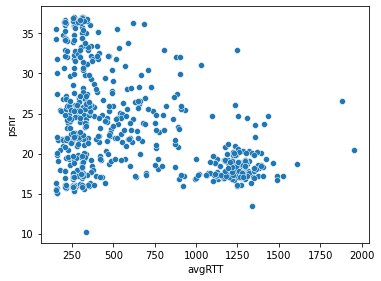

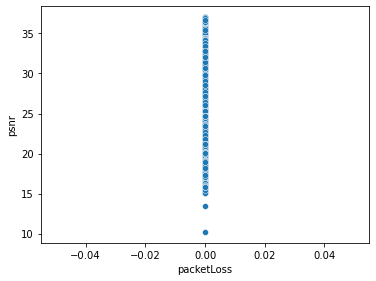

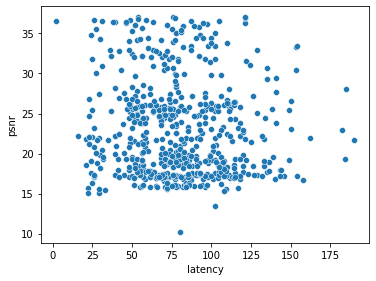

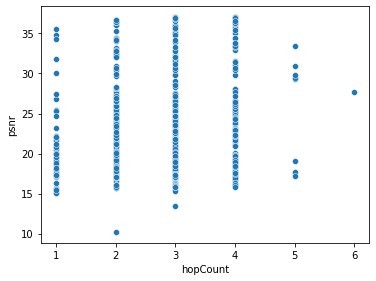

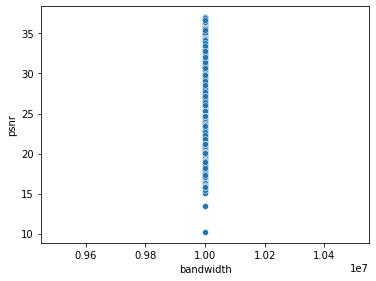

In [6]:
sayisal_veriler=["avgRTT","packetLoss","latency","hopCount","bandwidth"]
for i,deger in enumerate(sayisal_veriler):
    plt.figure(figsize=(20,20))
    ax=plt.subplot(4,3,i+1)
    sns.scatterplot(x=deger,y="psnr",data=df)
    plt.show()

In [7]:
# sns.displot(df)

In [8]:
df["mos"].value_counts()

mos
2    221
4    185
3    126
5     55
1      1
Name: count, dtype: int64

In [9]:
y=df["mos"]
x=df.drop(["mos","host","ssim_first","ssim_second","type","psnr","server","packetLoss","h10gelen","h10giden","h10toplam","h14gelen","h14giden","h14toplam"],axis="columns")
y


0      5
1      5
2      5
3      4
4      5
      ..
588    2
589    2
590    2
591    2
592    2
Name: mos, Length: 588, dtype: int64

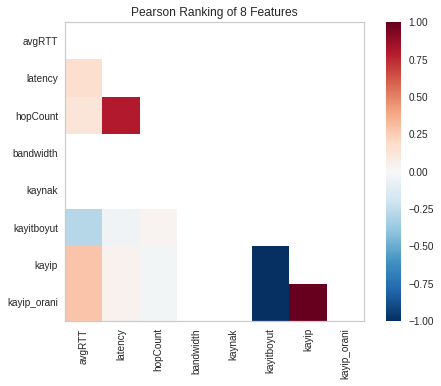

<AxesSubplot:title={'center':'Pearson Ranking of 8 Features'}>

In [10]:
from yellowbrick.features import Rank2D
visualizer=Rank2D(algorithm="pearson")
visualizer.fit(x,y)
visualizer.transform(x)
visualizer.show()

In [11]:
x.describe().T

,count,mean,std,min,25%,50%,75%,max
avgRTT,588.0,6.151730e+02,4.232686e+02,1.519770e+02,2.734425e+02,3.889160e+02,1.098511e+03,1.955956e+03
latency,588.0,7.927551e+01,3.047347e+01,2.000000e+00,5.700000e+01,7.800000e+01,9.925000e+01,1.900000e+02
hopCount,588.0,2.804422e+00,9.325721e-01,1.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,6.000000e+00
bandwidth,588.0,1.000000e+07,0.000000e+00,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07,1.000000e+07
kaynak,588.0,6.720981e+07,0.000000e+00,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07,6.720981e+07
kayitboyut,588.0,5.810413e+07,8.493663e+06,3.434086e+07,5.138022e+07,5.924454e+07,6.579814e+07,9.358541e+07
kayip,588.0,9.105684e+06,8.493663e+06,-2.637560e+07,1.411668e+06,7.965268e+06,1.582959e+07,3.286895e+07
kayip_orani,588.0,1.378799e+01,1.263753e+01,-3.900383e+01,2.340230e+00,1.209119e+01,2.379234e+01,4.914482e+01


In [13]:
from sklearn.model_selection import train_test_split
XTrain,XTest,yTrain,yTest=train_test_split(x,y,test_size=0.20, random_state=42)

In [14]:
yTest.value_counts()

mos
2    42
4    37
3    26
5    13
Name: count, dtype: int64

In [15]:
from sklearn.linear_model import LinearRegression
LinModel=LinearRegression()
LinModel.fit(XTrain,yTrain)
tahmin=LinModel.predict(XTest)
from sklearn.metrics import r2_score
print(r2_score(yTest,tahmin))

0.7873119286423303


In [16]:
from sklearn.ensemble import RandomForestRegressor
for i in range(1,20,1):
    rand=RandomForestRegressor(max_depth=i,)
    rand.fit(XTrain,yTrain)
    tahminRand=rand.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,rand.predict(XTrain))} test: {r2_score(yTest,tahminRand)}")

max_depth : 1 --> score r2 : eğitim:0.687369824763849 test: 0.7312479581919646
max_depth : 2 --> score r2 : eğitim:0.8051929828088714 test: 0.831064632836527
max_depth : 3 --> score r2 : eğitim:0.863082182748244 test: 0.8782917785604544
max_depth : 4 --> score r2 : eğitim:0.8891650574061201 test: 0.887225826102368
max_depth : 5 --> score r2 : eğitim:0.916275413549422 test: 0.897616089848464
max_depth : 6 --> score r2 : eğitim:0.9388114885823264 test: 0.8993807028006457
max_depth : 7 --> score r2 : eğitim:0.9549337008542169 test: 0.9021458247525738
max_depth : 8 --> score r2 : eğitim:0.9634612093944793 test: 0.8948999529561646
max_depth : 9 --> score r2 : eğitim:0.9699661200610247 test: 0.9012441953455752
max_depth : 10 --> score r2 : eğitim:0.969916375576291 test: 0.8924540793795798
max_depth : 11 --> score r2 : eğitim:0.9754758368029977 test: 0.8928772515958349
max_depth : 12 --> score r2 : eğitim:0.9745492011954231 test: 0.9015155359934478
max_depth : 13 --> score r2 : eğitim:0.97479

In [17]:
from sklearn.neighbors import KNeighborsRegressor
for i in range(1,20,1):
    KNN=KNeighborsRegressor(n_neighbors=i)
    KNN.fit(XTrain,yTrain)
    tahminKNN=KNN.predict(XTest)
    print(f"n_neigbors : {i} --> score r2 : eğitim:{r2_score(yTrain,KNN.predict(XTrain))} test: {r2_score(yTest,tahminKNN)}")

n_neigbors : 1 --> score r2 : eğitim:1.0 test: 0.7406938802690284
n_neigbors : 2 --> score r2 : eğitim:0.9275532598338284 test: 0.8605247386295531
n_neigbors : 3 --> score r2 : eğitim:0.8968745703306711 test: 0.8847528356751237
n_neigbors : 4 --> score r2 : eğitim:0.8828439953606492 test: 0.8826246920157155
n_neigbors : 5 --> score r2 : eğitim:0.8756550496056983 test: 0.8799334088033561
n_neigbors : 6 --> score r2 : eğitim:0.8726130745951467 test: 0.8742758207364987
n_neigbors : 7 --> score r2 : eğitim:0.8673274482928053 test: 0.8782848825752583
n_neigbors : 8 --> score r2 : eğitim:0.8600777339185699 test: 0.8725569354731304
n_neigbors : 9 --> score r2 : eğitim:0.8549188824229893 test: 0.8722386233873215
n_neigbors : 10 --> score r2 : eğitim:0.8555118161161389 test: 0.8760045282013718
n_neigbors : 11 --> score r2 : eğitim:0.8523012653238243 test: 0.8725873761802739
n_neigbors : 12 --> score r2 : eğitim:0.8519964323372909 test: 0.8712745924988716
n_neigbors : 13 --> score r2 : eğitim:0.

In [18]:
from sklearn.tree import DecisionTreeRegressor
for i in range(1,20,1):
    DT=DecisionTreeRegressor(max_depth=i)
    DT.fit(XTrain,yTrain)
    tahminDT=DT.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,DT.predict(XTrain))} test: {r2_score(yTest,tahminDT)}")

max_depth : 1 --> score r2 : eğitim:0.6488418895925623 test: 0.6951773572231852
max_depth : 2 --> score r2 : eğitim:0.7909621111564614 test: 0.8239516517932268
max_depth : 3 --> score r2 : eğitim:0.8433047787297895 test: 0.8461382413625557
max_depth : 4 --> score r2 : eğitim:0.87204351100583 test: 0.856144823996293
max_depth : 5 --> score r2 : eğitim:0.9054425355188888 test: 0.8578966619192372
max_depth : 6 --> score r2 : eğitim:0.9346261529839263 test: 0.8341653591182148
max_depth : 7 --> score r2 : eğitim:0.953363881140984 test: 0.8516516052846762
max_depth : 8 --> score r2 : eğitim:0.9697385172013183 test: 0.8026024779435907
max_depth : 9 --> score r2 : eğitim:0.9790554616570876 test: 0.7843052393629812
max_depth : 10 --> score r2 : eğitim:0.9845842600845209 test: 0.7737586177841983
max_depth : 11 --> score r2 : eğitim:0.9886054814264468 test: 0.7753046700965744
max_depth : 12 --> score r2 : eğitim:0.9938723036955686 test: 0.7695090122351131
max_depth : 13 --> score r2 : eğitim:0.99

In [19]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(1,10,1):
    gbr=GradientBoostingRegressor(max_depth=i,loss='squared_error')
    gbr.fit(XTrain,yTrain)
    tahminGbr=gbr.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,gbr.predict(XTrain))} test: {r2_score(yTest,tahminGbr)}")

max_depth : 1 --> score r2 : eğitim:0.8548755374399274 test: 0.8623892332009659
max_depth : 2 --> score r2 : eğitim:0.9008901527311965 test: 0.8872143194846358
max_depth : 3 --> score r2 : eğitim:0.9427250703403481 test: 0.889389978712727
max_depth : 4 --> score r2 : eğitim:0.9739536255721689 test: 0.8878190916090201
max_depth : 5 --> score r2 : eğitim:0.9918539436367899 test: 0.8647662928282214
max_depth : 6 --> score r2 : eğitim:0.9983135221473459 test: 0.8450861715091317
max_depth : 7 --> score r2 : eğitim:0.9998479729772237 test: 0.8182622579976215
max_depth : 8 --> score r2 : eğitim:0.999982562422496 test: 0.8320394178345369
max_depth : 9 --> score r2 : eğitim:0.9999986959194263 test: 0.835079811472825


In [20]:
from xgboost import XGBRegressor
xgb=XGBRegressor()
xgb.fit(XTrain,yTrain)
tahminXGB=xgb.predict(XTest)
print(r2_score(yTest,tahminXGB))

0.8369019747255377


In [21]:
from sklearn.linear_model import RANSACRegressor
ransac=RandomForestRegressor(random_state=42)
ransac.fit(XTrain,yTrain)
tahminRansac=ransac.predict(XTest)
print(f"ransac -> {r2_score(yTest,tahminRansac)}")

ransac -> 0.8930102949990011


In [31]:
tshminRansac2=tahminRansac.round()

In [33]:
print(f"ransac -> {r2_score(yTest,tshminRansac2)}")

ransac -> 0.858560298328561


In [22]:
from sklearn.ensemble import ExtraTreesRegressor
for i in range(1,10,1):
    exTree=ExtraTreesRegressor(max_depth=i)
    exTree.fit(XTrain,yTrain)
    tahminExTree=exTree.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,exTree.predict(XTrain))} test: {r2_score(yTest,tahminExTree)}")

max_depth : 1 --> score r2 : eğitim:0.6149651633566195 test: 0.6100276279123917
max_depth : 2 --> score r2 : eğitim:0.7537081265884811 test: 0.7602790344916481
max_depth : 3 --> score r2 : eğitim:0.8108942585766088 test: 0.8223562234739122
max_depth : 4 --> score r2 : eğitim:0.8552914743207791 test: 0.8719365351537831
max_depth : 5 --> score r2 : eğitim:0.8779340138557267 test: 0.8908500410297492
max_depth : 6 --> score r2 : eğitim:0.8987757807985941 test: 0.9003193252443099
max_depth : 7 --> score r2 : eğitim:0.9220094600769768 test: 0.9034919397438752
max_depth : 8 --> score r2 : eğitim:0.9462183512882415 test: 0.9079301272481528
max_depth : 9 --> score r2 : eğitim:0.9614698219681183 test: 0.8987515539111124


In [23]:
tahminGbr

array([2.00009683, 2.00004453, 1.99984679, 3.01199731, 3.98713778,
       3.99811112, 2.00004637, 3.21769693, 5.04247517, 3.99924646,
       2.4826854 , 4.00781756, 3.99936875, 2.00037189, 2.00004528,
       2.00005383, 3.96404468, 2.00003858, 4.48471419, 3.00003376,
       3.00240292, 3.52444085, 3.60003813, 2.00004528, 2.0001495 ,
       4.00413243, 3.98568017, 2.00003849, 2.00002988, 2.99777328,
       2.00013259, 1.9999988 , 2.00004742, 2.00004637, 3.99695181,
       2.00004052, 2.00019548, 2.99909021, 2.00004528, 2.9991299 ,
       2.0001155 , 3.00162424, 4.79053961, 3.87105114, 3.99754611,
       3.99937337, 3.2988931 , 2.0012075 , 2.00017815, 4.0000448 ,
       4.94799649, 3.00780392, 3.90092831, 2.00004528, 2.00004453,
       2.98871471, 4.00037138, 3.96112319, 2.99861928, 2.00011659,
       4.00798968, 2.99836267, 4.01623786, 3.78166243, 5.12305415,
       3.95099921, 4.0006445 , 2.00004453, 2.00025272, 2.00002184,
       4.23499289, 2.18410929, 2.00004528, 3.99151996, 2.98871

In [29]:
yTest.array[42]

5

In [25]:
yTrain
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
XTrain[sayisal_veriler]=scaler.fit_transform(XTrain[sayisal_veriler])
XTest[sayisal_veriler]=scaler.transform(XTest[sayisal_veriler])

131    3
153    3
77     4
440    2
257    5
      ..
71     3
106    4
272    2
438    2
102    4
Name: mos, Length: 470, dtype: int64

In [ ]:
from sklearn.linear_model import LinearRegression
LogModel=LinearRegression()
LogModel.fit(XTrain,yTrain)
tahmin=LogModel.predict(XTest)
from sklearn.metrics import r2_score
print(r2_score(yTest,tahmin))

-4.642549972693122


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
for i in range(1,20,1):
    KNN=KNeighborsRegressor(n_neighbors=i)
    KNN.fit(XTrain,yTrain)
    tahminKNN=KNN.predict(XTest)
    print(f"n_neigbors : {i} --> score r2 : eğitim:{r2_score(yTrain,KNN.predict(XTrain))} test: {r2_score(yTest,tahminKNN)}")

n_neigbors : 1 --> score r2 : eğitim:1.0 test: -71.4195313685805
n_neigbors : 2 --> score r2 : eğitim:0.5408173794694464 test: -30.180746540462962
n_neigbors : 3 --> score r2 : eğitim:0.38098304140622574 test: -12.35957091007418
n_neigbors : 4 --> score r2 : eğitim:0.3281552469486244 test: -9.492854763586301
n_neigbors : 5 --> score r2 : eğitim:0.2724046958868013 test: -7.497837930339246
n_neigbors : 6 --> score r2 : eğitim:0.23108394497407914 test: -4.9427443097501085
n_neigbors : 7 --> score r2 : eğitim:0.19209244775566126 test: -3.456755754337749
n_neigbors : 8 --> score r2 : eğitim:0.17602631125580537 test: -2.5576503781062625
n_neigbors : 9 --> score r2 : eğitim:0.1710088829317742 test: -1.8517249772630833
n_neigbors : 10 --> score r2 : eğitim:0.161902013384302 test: -1.29895426405142
n_neigbors : 11 --> score r2 : eğitim:0.15543368650474965 test: -0.9510317016514858
n_neigbors : 12 --> score r2 : eğitim:0.1437638012141057 test: -0.7309591890051519
n_neigbors : 13 --> score r2 : e

In [ ]:
from sklearn.ensemble import RandomForestRegressor
for i in range(1,20,1):
    rand=RandomForestRegressor(max_depth=i,bootstrap=True,criterion="friedman_mse",max_features='log2',max_leaf_nodes=None,n_estimators=100,n_jobs=1,random_state=42)
    rand.fit(XTrain,yTrain)
    tahminRand=rand.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,rand.predict(XTrain))} test: {r2_score(yTest,tahminRand)}")

max_depth : 1 --> score r2 : eğitim:0.11064440698553679 test: -0.9106493394064936
max_depth : 2 --> score r2 : eğitim:0.3096475043477387 test: -2.5628808061754627
max_depth : 3 --> score r2 : eğitim:0.519910586117451 test: -4.368034996632447
max_depth : 4 --> score r2 : eğitim:0.6688130935161649 test: -9.106353582307468
max_depth : 5 --> score r2 : eğitim:0.7728111715877166 test: -8.516749120595469
max_depth : 6 --> score r2 : eğitim:0.8164965810486424 test: -7.56924805780395
max_depth : 7 --> score r2 : eğitim:0.8287055299351374 test: -7.168315973295311
max_depth : 8 --> score r2 : eğitim:0.8379512271295804 test: -13.43677374330953
max_depth : 9 --> score r2 : eğitim:0.8404991309431038 test: -10.848339395190308
max_depth : 10 --> score r2 : eğitim:0.8342687130109395 test: -9.247283975873103
max_depth : 11 --> score r2 : eğitim:0.8334497439097873 test: -8.47899860081651
max_depth : 12 --> score r2 : eğitim:0.8336238361783528 test: -9.034320291977089
max_depth : 13 --> score r2 : eğitim

In [ ]:
from sklearn.tree import DecisionTreeRegressor
for i in range(1,20,1):
    DT=DecisionTreeRegressor(max_depth=i)
    DT.fit(XTrain,yTrain)
    tahminDT=DT.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,DT.predict(XTrain))} test: {r2_score(yTest,tahminDT)}")

max_depth : 1 --> score r2 : eğitim:0.10061124789406062 test: -0.498523431015212
max_depth : 2 --> score r2 : eğitim:0.19853967411969042 test: -3.4609577066576245
max_depth : 3 --> score r2 : eğitim:0.47647685872718815 test: -34.026308787957454
max_depth : 4 --> score r2 : eğitim:0.7240636388469759 test: -74.40562190798799
max_depth : 5 --> score r2 : eğitim:0.9795529020264285 test: -71.84859497418822
max_depth : 6 --> score r2 : eğitim:0.9833826811387384 test: -72.23760624774027
max_depth : 7 --> score r2 : eğitim:0.987429990338354 test: -71.81432255107657
max_depth : 8 --> score r2 : eğitim:0.9962372899385743 test: -0.8874550010499995
max_depth : 9 --> score r2 : eğitim:0.9985824148972497 test: -72.3241338088478
max_depth : 10 --> score r2 : eğitim:0.9994861256924849 test: -72.25017967653562
max_depth : 11 --> score r2 : eğitim:0.9999807542844047 test: -72.25910849711639
max_depth : 12 --> score r2 : eğitim:0.9999971943186402 test: -72.73617135538156
max_depth : 13 --> score r2 : eği

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
for i in range(1,10,1):
    gbr=GradientBoostingRegressor(max_depth=i,loss='squared_error')
    gbr.fit(XTrain,yTrain)
    tahminGbr=gbr.predict(XTest)
    print(f"max_depth : {i} --> score r2 : eğitim:{r2_score(yTrain,gbr.predict(XTrain))} test: {r2_score(yTest,tahminGbr)}")

max_depth : 1 --> score r2 : eğitim:0.33883339404507307 test: -2.377428860412824
max_depth : 2 --> score r2 : eğitim:0.9562457199999259 test: -17.661178948117293
max_depth : 3 --> score r2 : eğitim:0.987890892239113 test: -23.594518654870196
max_depth : 4 --> score r2 : eğitim:0.9989850375313967 test: -29.953745493628936
max_depth : 5 --> score r2 : eğitim:0.9998685829132781 test: -42.365264581535754
max_depth : 6 --> score r2 : eğitim:0.9999693439964115 test: -49.80191283096458
max_depth : 7 --> score r2 : eğitim:0.9999989030738063 test: -33.286911678722895
max_depth : 8 --> score r2 : eğitim:0.9999998522010303 test: -56.287910237405455
max_depth : 9 --> score r2 : eğitim:0.9999999948824845 test: -58.865711456639865
